# Whitson Appendix B: equilibrium and LBC examples

This notebook independently reconstructs the equilibrium-related examples in
Appendix B of C. H. Whitson and M. R. Brulé, *Phase Behavior*, SPE Monograph
20 (2000), ISBN 978-1-55563-087-4:

- Problem 7, Tables B-11 and B-12: Lohrenz-Bray-Clark viscosity;
- Problem 15, Tables B-18 through B-21: a Rachford-Rice split using the
  printed equilibrium ratios; and
- Problem 18, Tables B-28 through B-32: PR78 flashes of C1/n-C4/n-C10 at
  500 and 1500 psia and 280°F.

The calculations use only values printed in the monograph. This matters:
rounded K values in Problem 15 cannot reproduce all digits of the book's
iteration table. The discrepancy is reported, not hidden by reverse fitting.

In [1]:
from __future__ import annotations

import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import display

from torch_flash import ChemicalState, component_set, peng_robinson_1978
from torch_flash.components import ComponentSet
from torch_flash.flash import two_phase_flash
from torch_flash.material_balance import rachford_rice
from torch_flash.transport import lbc_viscosity

torch.set_default_dtype(torch.float64)
plt.style.use("seaborn-v0_8-whitegrid")
PSIA_TO_PA = 6894.757293168
FT3_PER_LBMOL_TO_M3_PER_MOL = 0.028316846592 / 453.59237

## Problem 7: LBC gas viscosity

The tabulated state is 2015 psia and 160°F. Whitson reports a mixture
pseudocritical molar volume of 1.752 ft³/lbmol, reduced density 0.627, dilute
viscosity 0.0121 cP, and final LBC viscosity 0.0166 cP. The low-density term
uses Stiel-Thodos and Herning-Zipperer; the dense correction uses the
original LBC fourth-degree reduced-density polynomial.

In [2]:
lbc_names = (
    "methane",
    "ethane",
    "propane",
    "isobutane",
    "n_butane",
    "isopentane",
    "n_pentane",
    "n_hexane",
    "n_octane",  # the printed C7+ has the n-octane constants in Table B-12
)
lbc_z = torch.tensor([0.875, 0.083, 0.021, 0.006, 0.008, 0.003, 0.002, 0.001, 0.001])
lbc_vc = (
    torch.tensor([1.590, 2.370, 3.250, 4.208, 4.080, 4.899, 4.870, 5.929, 7.882])
    * FT3_PER_LBMOL_TO_M3_PER_MOL
)
lbc_temperature = torch.tensor(620.0 / 1.8)  # book rounds 160°F to 620°R
lbc_mixture_vc = 1.752 * FT3_PER_LBMOL_TO_M3_PER_MOL
lbc_density = torch.tensor(0.627 / lbc_mixture_vc)
lbc_value = lbc_viscosity(
    lbc_temperature,
    lbc_density,
    lbc_z,
    component_set(lbc_names),
    critical_volume=lbc_vc,
)
lbc_comparison = pd.DataFrame(
    {
        "source": ["Whitson Table B-12", "torch-flash"],
        "viscosity_cP": [0.0166, float(1000.0 * lbc_value)],
    }
)
display(lbc_comparison)
assert abs(float(1000.0 * lbc_value) - 0.0166) < 2.5e-4

,source,viscosity_cP
0,Whitson Table B-12,0.016600
1,torch-flash,0.016352


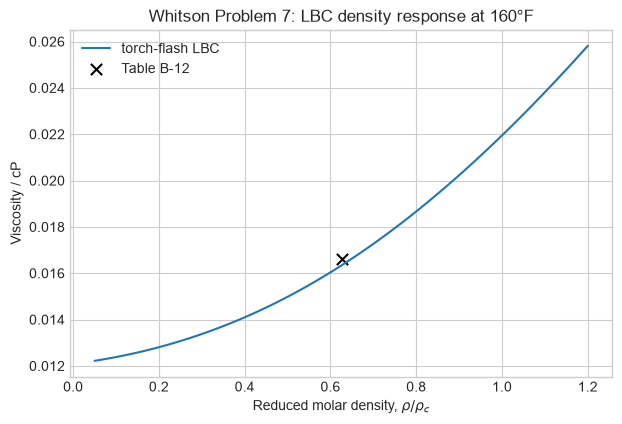

In [3]:
reduced_density = torch.linspace(0.05, 1.2, 100)
lbc_curve = torch.stack(
    [
        lbc_viscosity(
            lbc_temperature,
            value / lbc_mixture_vc,
            lbc_z,
            component_set(lbc_names),
            critical_volume=lbc_vc,
        )
        for value in reduced_density
    ]
)
fig, axis = plt.subplots(figsize=(7, 4.5))
axis.plot(reduced_density, 1000.0 * lbc_curve, label="torch-flash LBC")
axis.scatter([0.627], [0.0166], color="black", marker="x", s=65, label="Table B-12")
axis.set(
    xlabel=r"Reduced molar density, $\rho/\rho_c$",
    ylabel="Viscosity / cP",
    title="Whitson Problem 7: LBC density response at 160°F",
)
axis.legend()
plt.show()

LBC is fast and differentiable, but Pedersen (2024, §10.1.3) cautions that
it is usually a low-quality predictive model for heavy oils. Its critical
volumes or polynomial coefficients should therefore be treated as explicit
fitting parameters when viscosity data are available.

## Problem 15: material balance with printed K values

Tables B-18 and B-19 give \(z=(0.20,0.32,0.48)\) and
\(K=(9.208,1.439,0.358)\). Table B-20 reports
\(\beta_v=0.48242\). Solving the exact equation with the *printed,
three-decimal* K values gives 0.48291; this is a rounding audit, not a solver
error.

In [4]:
rr_z = torch.tensor([0.20, 0.32, 0.48])
rr_k = torch.tensor([9.208, 1.439, 0.358])
rr = rachford_rice(rr_z, rr_k)
rr_table = pd.DataFrame(
    {
        "component": ["C1", "C3", "n-C5"],
        "z": rr_z.numpy(),
        "K_printed": rr_k.numpy(),
        "x_torch": rr.liquid_composition.numpy(),
        "x_book": [0.0403, 0.2641, 0.6956],
        "y_torch": rr.vapor_composition.numpy(),
        "y_book": [0.3713, 0.3800, 0.2487],
    }
)
display(rr_table)
print(f"beta from printed K = {float(rr.vapor_fraction):.8f}")
print("Table B-20 beta      = 0.48242000")

,component,z,K_printed,x_torch,x_book,y_torch,y_book
0,C1,0.20,9.208,0.040292,0.0403,0.371012,0.3713
1,C3,0.32,1.439,0.264027,0.2641,0.379935,0.3800
2,n-C5,0.48,0.358,0.695681,0.6956,0.249054,0.2487


beta from printed K = 0.48291022
Table B-20 beta      = 0.48242000


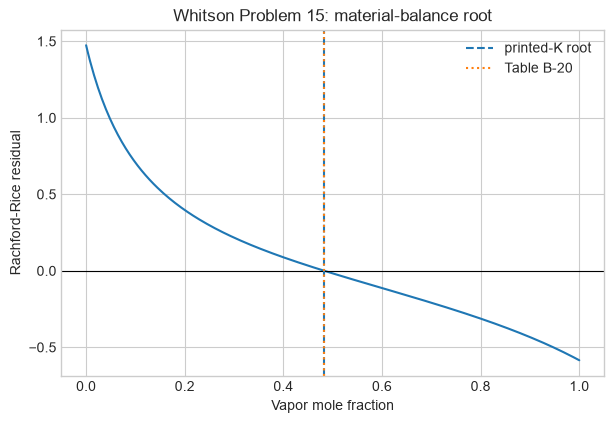

In [5]:
beta_grid = torch.linspace(0.0, 1.0, 250)
rr_residual = torch.sum(
    rr_z * (rr_k - 1.0) / (1.0 + beta_grid[:, None] * (rr_k - 1.0)),
    dim=1,
)
fig, axis = plt.subplots(figsize=(7, 4.5))
axis.plot(beta_grid, rr_residual)
axis.axhline(0.0, color="black", linewidth=0.8)
axis.axvline(
    float(rr.vapor_fraction), color="tab:blue", linestyle="--", label="printed-K root"
)
axis.axvline(0.48242, color="tab:orange", linestyle=":", label="Table B-20")
axis.set(
    xlabel="Vapor mole fraction",
    ylabel="Rachford-Rice residual",
    title="Whitson Problem 15: material-balance root",
)
axis.legend()
plt.show()

## Problem 18: PR78 flash and stability-derived second state

Table B-28 defines the ternary. Table B-30 reports a flash at 500 psia;
Tables B-31/B-32 report the stability analysis and converged flash at
1500 psia. The book uses the 1978 high-accentric-factor extension for
n-decane, exactly the `PR78` variant used below.

In [6]:
problem18_components = ComponentSet(
    ("methane", "n_butane", "n_decane"),
    torch.tensor([343.0, 765.3, 1111.8]) / 1.8,
    torch.tensor([667.8, 550.7, 304.0]) * PSIA_TO_PA,
    torch.tensor([0.0115, 0.1928, 0.4902]),
    torch.tensor([16.04, 58.12, 142.29]) / 1000.0,
)
problem18_model = peng_robinson_1978(problem18_components)
problem18_z = torch.tensor([0.50, 0.42, 0.08])
problem18_temperature = torch.tensor(740.0 / 1.8)
problem18_reference = {
    500.0: {
        "beta": 0.853401,
        "x": [0.08588, 0.46349, 0.45064],
        "y": [0.57114, 0.41253, 0.01633],
    },
    1500.0: {
        "beta": 0.566844,
        "x": [0.330082, 0.513307, 0.156611],
        "y": [0.629843, 0.348699, 0.021457],
    },
}

flash_rows: list[dict[str, float | str]] = []
flash_results = {}
for pressure_psia, reference in problem18_reference.items():
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        result = two_phase_flash(
            problem18_model,
            ChemicalState(
                problem18_temperature,
                torch.tensor(pressure_psia * PSIA_TO_PA),
                problem18_z,
            ),
            check_stability=False,
        )
    flash_results[pressure_psia] = result
    for phase_index, phase_name in enumerate(("liquid", "vapor")):
        reference_composition = (
            reference["x"] if phase_name == "liquid" else reference["y"]
        )
        for name, calculated, published in zip(
            problem18_components.names,
            result.phases[phase_index].composition,
            reference_composition,
            strict=True,
        ):
            flash_rows.append(
                {
                    "pressure_psia": pressure_psia,
                    "phase": phase_name,
                    "component": name,
                    "torch_flash": float(calculated),
                    "Whitson": published,
                }
            )
flash_comparison = pd.DataFrame(flash_rows)
display(flash_comparison)

,pressure_psia,phase,component,torch_flash,Whitson
0,500.0,liquid,methane,0.085922,0.085880
1,500.0,liquid,n_butane,0.462863,0.463490
2,500.0,liquid,n_decane,0.451216,0.450640
3,500.0,vapor,methane,0.570772,0.571140
4,500.0,vapor,n_butane,0.412674,0.412530
5,500.0,vapor,n_decane,0.016554,0.016330
6,1500.0,liquid,methane,0.330387,0.330082
7,1500.0,liquid,n_butane,0.513028,0.513307
8,1500.0,liquid,n_decane,0.156586,0.156611
9,1500.0,vapor,methane,0.629119,0.629843


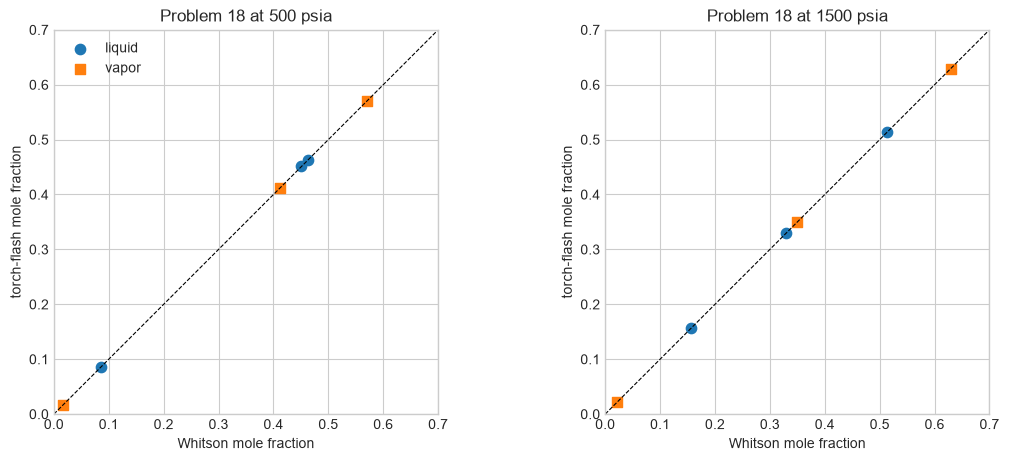

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), constrained_layout=True)
for axis, pressure_psia in zip(axes, problem18_reference, strict=True):
    group = flash_comparison[flash_comparison["pressure_psia"] == pressure_psia]
    for phase, marker in (("liquid", "o"), ("vapor", "s")):
        phase_group = group[group["phase"] == phase]
        axis.scatter(
            phase_group["Whitson"],
            phase_group["torch_flash"],
            marker=marker,
            s=55,
            label=phase,
        )
    axis.plot([0, 0.7], [0, 0.7], "k--", linewidth=0.8)
    axis.set(
        xlim=(0, 0.7),
        ylim=(0, 0.7),
        aspect="equal",
        xlabel="Whitson mole fraction",
        ylabel="torch-flash mole fraction",
        title=f"Problem 18 at {pressure_psia:.0f} psia",
    )
axes[0].legend()
plt.show()

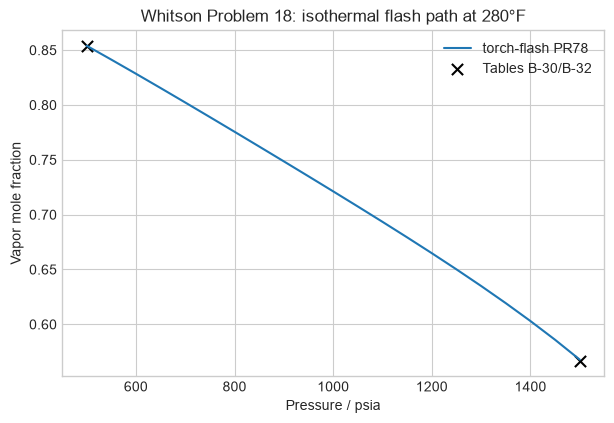

In [8]:
pressure_grid = np.linspace(500.0, 1500.0, 21)
vapor_fraction = []
for pressure_psia in pressure_grid:
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        result = two_phase_flash(
            problem18_model,
            ChemicalState(
                problem18_temperature,
                torch.tensor(pressure_psia * PSIA_TO_PA),
                problem18_z,
            ),
            check_stability=False,
        )
    vapor_fraction.append(float(result.phase_fractions[1]))
fig, axis = plt.subplots(figsize=(7, 4.5))
axis.plot(pressure_grid, vapor_fraction, label="torch-flash PR78")
axis.scatter(
    list(problem18_reference),
    [value["beta"] for value in problem18_reference.values()],
    color="black",
    marker="x",
    s=65,
    label="Tables B-30/B-32",
)
axis.set(
    xlabel="Pressure / psia",
    ylabel="Vapor mole fraction",
    title="Whitson Problem 18: isothermal flash path at 280°F",
)
axis.legend()
plt.show()

## Conclusions

- The LBC implementation reproduces the rounded Problem 7 result.
- The Rachford-Rice solver exactly solves the equation implied by the printed
  Problem 15 K values; the 0.00049 difference in vapor fraction is explained
  by input rounding.
- PR78 reproduces both Problem 18 equilibrium states, including the
  high-pressure split obtained after Michelsen stability analysis.